# 02. 정책 스코어링, 정규화, 가중치 산출, 미스매치 분석

이 노트북은 전처리된 온통청년 정책 데이터를 바탕으로 지역별 **정책지원점수**를 산출합니다.  
팀원들이 만든 채용공고 기반 `일자리취약도` 파일이 있으면, 이를 결합해 **정책 미스매치 점수**까지 계산합니다.

## 기본 개념

- **정책지원점수**: 해당 지역에 청년정책이 얼마나 충분하고, 일자리 관련성이 있으며, 정보가 구체적으로 제공되는지를 0~100점으로 환산한 점수
- **일자리취약도**: 채용공고 분석팀이 산출한 지역별 일자리 문제 정도. 높을수록 취약한 지역
- **정책 미스매치 점수**: 일자리취약도는 높은데 정책지원점수가 낮을수록 높아지는 점수

## 정책지원점수 구성

| 지표 | 의미 | 가중치 |
|---|---|---:|
| 정책규모 점수 | 지역별 정책 수를 Min-Max 정규화 | 0.25 |
| 일자리·교육 집중도 | 일자리/직무교육 정책 비율을 정규화 | 0.25 |
| 분야 다양성 | 정책분야 분포의 Shannon entropy 기반 다양성 | 0.20 |
| 정보 구체성 | 정책 설명·지원내용 등 분석 텍스트 평균 길이 정규화 | 0.15 |
| 접근성 | 신청URL/참고URL 존재 비율 | 0.15 |

> 주의: 이 점수는 정책 효과를 직접 측정한 것이 아니라, API 텍스트 자료 기준의 **정책 공급·정보 제공 수준**을 나타내는 프로젝트용 지표입니다.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 80)

DATA_DIR = Path(".")
OUTPUT_DIR = DATA_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

PREPROCESSED_FILE = OUTPUT_DIR / "policy_preprocessed.csv"
RAW_POLICY_FILE = DATA_DIR / "youth_policies_categorized.csv"

def read_csv_auto(path: Path) -> pd.DataFrame:
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return pd.read_csv(path)

if PREPROCESSED_FILE.exists():
    df = read_csv_auto(PREPROCESSED_FILE)
    print("전처리 파일 로드:", PREPROCESSED_FILE)
elif RAW_POLICY_FILE.exists():
    df = read_csv_auto(RAW_POLICY_FILE)
    print("전처리 파일이 없어 원본 파일을 로드했습니다. 가능하면 01번 노트북을 먼저 실행하세요.")
else:
    raise FileNotFoundError("policy_preprocessed.csv 또는 youth_policies_categorized.csv를 찾을 수 없습니다.")

print("데이터 크기:", df.shape)
display(df.head())

전처리 파일 로드: outputs\policy_preprocessed.csv
데이터 크기: (5470, 52)


,지역,조회_zipCd,정책ID,정책명,정책키워드,정책설명,정책지원내용,정책대분류,정책중분류,자동분류,대표분류,신청기간,사업기간,지원대상,나이조건,소득조건,신청방법,제출서류,주관기관,운영기관,신청URL,참고URL1,참고URL2,최초등록일시,최종수정일시,수집페이지,수집출처,정책ID_정리,정책명_정리,지역_정리,_최종수정일시_dt,대표분류_기존정리,대표분류_정리,분류변경여부,분석텍스트_원본,분석텍스트,분석텍스트길이,URL존재여부,지원대상존재여부,신청방법존재여부,제출서류존재여부,신청시작일,신청종료일,사업시작일,사업종료일,신청기간_기재여부,신청기간_날짜추출여부,신청기간_상시성여부,사업기간_기재여부,사업기간_날짜추출여부,사업기간_상시성여부,현재신청가능추정
0,강원,"51000,42000",20260605005400113228,청년미래적금,보조금,"청년들의 기초자산 형성을 지원하기 위한 정책형 금융상품으로, 3년 만기 시까지 매월 최대 50만원 한도 내에서 자유롭게 납입 가능(202...","은행이자+비과세 혜택+정부기여금(납입금액에 비례해 일반형 6%, 우대형 12%의 정부기여금 지원)",금융･복지･문화,취약계층 및 금융지원,복지,복지,20260622 ~ 20261231,20260622 ~ 20261231,"19세~34세 / 연령제한:N 0043003 0 0 총급여 7,500만원 이하 또는 연매출 3억원 이하 소상공인 중 가구 중위소득 200...",19세~34세 / 연령제한:N,"0043003 0 0 총급여 7,500만원 이하 또는 연매출 3억원 이하 소상공인 중 가구 중위소득 200% 이하인 청년을 대상",ㅇ 취급은행 모바일앱을 통해 매월 비대면 신청 가능 ㅇ 2026년 6월 출시 예정,NaN,금융위원회,한국고용정보원,NaN,https://www.kinfa.or.kr/financialProduct/youthFutureSavings.do,https://blog.naver.com/blogfsc/224302863400,2026-06-05 18:06:49,2026-06-10 14:05:31,1,온통청년_OPEN_API_getPlcy,20260605005400113228,청년미래적금,강원,2026-06-10 14:05:31,복지,복지,0,"청년미래적금 보조금 청년들의 기초자산 형성을 지원하기 위한 정책형 금융상품으로, 3년 만기 시까지 매월 최대 50만원 한도 내에서 자유롭...","청년미래적금 보조금 청년들의 기초자산 형성을 지원하기 위한 정책형 금융상품으로, 3년 만기 시까지 매월 최대 50만원 한도 내에서 자유롭...",302,1,1,1,0,2026-06-22 00:00:00,2026-12-31 00:00:00,2026-06-22 00:00:00,2026-12-31 00:00:00,1,1,0,1,1,0,0
1,강원,"51000,42000",20250114005400210229,스마트 모빌리티 창업캠프사업,교육지원,"미래모빌리티 분야 창업을 희망하는 청년을 대상으로 국내 자동차업계 마이스터들의 강연, 멘토링, 카운슬링을 지원하여 창업아이디어를 구체화하...","1. (사전프로그램) 기업가정신 함양, 멘토링, 카운슬링 2. (집합프로그램) - 자동차산업 전망, 창업 핵심기반, 기업가정신 등 교육지...","일자리,일자리","취업,창업","일자리, 직무교육, 창업지원, 참여 프로그램",일자리,20260401 ~ 20260528,20260301 ~ 20261231,"0세~0세 / 연령제한:Y 0043001 0 0 모빌리티 분야(관련) 전공 대학(원)생 0011003,0011004,0011005 001...",0세~0세 / 연령제한:Y,0043001 0 0,공고에 따라 지원서 작성 후 이메일 제출(신청기간 연장~5/28),대학생 스마트 모빌리티 창업캠프 지원서,미래모빌리티과,대구광역시 미래혁신성장실,https://www.kaae.kr/,https://www.kaae.kr/,NaN,2025-01-14 11:00:54,2026-05-29 14:57:57,5,온통청년_OPEN_API_getPlcy,20250114005400210229,스마트 모빌리티 창업캠프사업,강원,2026-05-29 14:57:57,일자리,창업지원,1,"스마트 모빌리티 창업캠프사업 교육지원 미래모빌리티 분야 창업을 희망하는 청년을 대상으로 국내 자동차업계 마이스터들의 강연, 멘토링, 카운...","스마트 모빌리티 창업캠프사업 교육지원 미래모빌리티 분야 창업을 희망하는 청년을 대상으로 국내 자동차업계 마이스터들의 강연, 멘토링, 카운...",414,1,1,1,1,2026-04-01 00:00:00,2026-05-28 00:00:00,2026-03-01 00:00:00,2026-12-31 00:00:00,1,1,0,1,1,0,0
2,강원,"51000,42000",20250714005400111227,산림산업 창업지원_청년 임팩트 창업 아이디어 챌린지,"교육지원,맞춤형상담서비스,장기미취업청년",산림자원을 활용 기반의 산림 문제 해결형 사업 공모전 개최 및 실증 과정을 통한 청년 창업 경험 지원,ㅇ 공모전명 : 2026 청년 林팩트 창업 아이디어 챌린지 ㅇ 주요내용 : 산림자원을 활용 기반의 산림 문제 해결형 사업 공모전 개최 및...,"일자리,일자리","취업,창업","일자리, 직무교육, 창업지원, 복지, 참여 프로그램",일자리,20260520 ~ 20260603,20260622 ~ 20260623,19세~39세 / 연령제한:N 0043001 0 0 산림창업에 관심있는 청년(만19세 ~ 39세) 누구나 0011009 0013010 0...,19세~39세 / 연령제한:N,0043001 0 0,NaN,1. 신청사이트 URL을 통하여 참가신청서 작성 2. 한국임업진흥원 누리집(www.kofpi.or.kr)의 ‘알림/홍보’ - ‘공지사항’...,산림청,한국임업진흥원,https://docs.google.com/forms/u/0/d/1-QTMyaKxeBcQvtNYkMlNIkhtZ-K1lxyVEBMDn9W...,www.kofpi.or.kr,NaN,2025-07-14 22:19:33,2026-05-29 11:08:25,2,온통청년_OPEN_API_getPlcy,20250714005400111227,산림산업 창업지원_청년 임팩트 창업 아이디어 챌린지,강원,2026-05-29 11:08:25,일자리,창업지원,1,"산림산업 창업지원_청년 임팩트 창업 아이디어 챌린지 교육지원,맞춤형상담서비스,장기미취업청년 산림자원을 활용 기반의 산림 문제 해결형 사업...","산림산업 창업지원_청년 임팩트 창업 아이디어 챌린지 교육지원,맞춤형상담서비스,장기미취업청년 산림자원을 활용 기반의 산림 문제 해결형 사업...",502,1,1,0,1,2026-05-20 00:00:00,2026-06-03 00:00:00,2026-06-22 00:00:00,2026-06-23 00:00:00,1,1,0,1,1,0,0
3,강원,"51000,42000",20260528005400113227,(농식품부) 농식품 바우처,바우처,『농업·농촌 및 식품산업 기본법』 제 23조의 2(취약계층 등에 대한 식품지원)에 근거하여 취약계층의 식품 접근성을 강화하고 균형 있는 ...,"- 지원방식: 전자바우처(카드방식) - 지원품목: 국산 채소류, 과일류, 육류, 신선알류, 흰 우유, 잡곡류, 두부류, 임산물 (이외 품...",금융･복지･문화,건강,복지,복지,20251222 ~ 20261211,20260102 ~ 20261231,18세~34세 / 연령제한:N 0043003 0 0 생계급여(기준 중위소득 32%이하) 수급가구 중 임산부·영유아·아동·청년 포함가구 생...,18세~34세 / 연령제한:N,0043003 0 0 생계급여(기준 중위소득 32%이하) 수급가구 중 임산부·영유아·아동·청년 포함가구,1. 방문신청 : 주소지 관할 읍ㆍ면ㆍ동 행정복지센터 방문 2. 전화신청 : 고객지원센터 (1551-0857)를 통해 신청 3. 온라인신...,NaN,농림축산식품부,한국고용정보원,https://www.foodvoucher.go.kr/security/joinAgree,https://www.foodvoucher.go.kr/view/fm/vucintro/agriF

In [3]:
# 필요한 파생 컬럼이 없는 경우 보정
if "대표분류_정리" not in df.columns:
    df["대표분류_정리"] = df.get("대표분류", df.get("자동분류", "기타")).fillna("기타")

if "분석텍스트길이" not in df.columns:
    text_cols = [c for c in ["정책명", "정책키워드", "정책설명", "정책지원내용", "지원대상", "신청방법"] if c in df.columns]
    df["분석텍스트길이"] = df[text_cols].fillna("").agg(" ".join, axis=1).str.len()

if "URL존재여부" not in df.columns:
    url_cols = [c for c in ["신청URL", "참고URL1", "참고URL2"] if c in df.columns]
    df["URL존재여부"] = df[url_cols].fillna("").apply(lambda row: any(str(x).strip() for x in row), axis=1).astype(int)

print(df[["지역", "정책명", "대표분류_정리", "분석텍스트길이", "URL존재여부"]].head())

   지역                           정책명 대표분류_정리  분석텍스트길이  URL존재여부
0  강원                        청년미래적금      복지      302        1
1  강원               스마트 모빌리티 창업캠프사업    창업지원      414        1
2  강원  산림산업 창업지원_청년 임팩트 창업 아이디어 챌린지    창업지원      502        1
3  강원                (농식품부) 농식품 바우처      복지      731        1
4  강원                 삼척형 청년인턴 지원사업     일자리      323        1


In [4]:
def minmax_0_100(series: pd.Series) -> pd.Series:
    """Min-Max 정규화 후 0~100점으로 변환. 값이 모두 같으면 50점 처리."""
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    min_v, max_v = s.min(), s.max()
    if max_v == min_v:
        return pd.Series(50.0, index=s.index)
    return (s - min_v) / (max_v - min_v) * 100

def shannon_diversity(counts):
    """분야 다양성 계산. 여러 분야에 고르게 분포할수록 1에 가까움."""
    counts = np.array(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    entropy = -(p * np.log(p)).sum()
    max_entropy = np.log(len(counts)) if len(counts) > 1 else 1
    return entropy / max_entropy if max_entropy > 0 else 0.0

In [5]:
# 지역별 기본 집계
category_order = ["일자리", "직무교육", "주거지원", "창업지원", "복지", "참여 프로그램", "기타"]

region_category = (
    pd.pivot_table(
        df,
        index="지역",
        columns="대표분류_정리",
        values="정책명",
        aggfunc="count",
        fill_value=0
    )
    .reindex(columns=category_order, fill_value=0)
)

region_base = (
    df.groupby("지역", as_index=False)
      .agg(
          정책수=("정책명", "count"),
          평균텍스트길이=("분석텍스트길이", "mean"),
          URL존재율=("URL존재여부", "mean"),
      )
)

job_edu_count = region_category.get("일자리", 0) + region_category.get("직무교육", 0)
region_base = region_base.merge(
    job_edu_count.rename("일자리교육정책수").reset_index(),
    on="지역",
    how="left"
)
region_base["일자리교육정책비율"] = region_base["일자리교육정책수"] / region_base["정책수"]

diversity = region_category.apply(lambda row: shannon_diversity(row.values), axis=1)
region_base = region_base.merge(diversity.rename("분야다양성").reset_index(), on="지역", how="left")

display(region_base.sort_values("정책수", ascending=False))

,지역,정책수,평균텍스트길이,URL존재율,일자리교육정책수,일자리교육정책비율,분야다양성
8,충남,707,323.004243,0.816124,297,0.420085,0.882262
7,제주,608,405.138158,0.800987,278,0.457237,0.884747
2,경남,584,394.638699,0.833904,269,0.460616,0.880136
3,경북,539,415.497217,0.788497,242,0.448980,0.885228
5,전남,535,395.276636,0.753271,235,0.439252,0.890107
6,전북,534,398.061798,0.720974,241,0.451311,0.877290
1,경기,515,396.398058,0.811650,240,0.466019,0.878498
9,충북,498,412.483936,0.751004,237,0.475904,0.878697
0,강원,489,410.584867,0.754601,235,0.480573,0.870226
4,서울,461,453.585683,0.750542,210,0.455531,0.880922


In [6]:
# 정규화 점수 산출
score_df = region_base.copy()

score_df["정책규모점수"] = minmax_0_100(score_df["정책수"])
score_df["일자리교육집중도점수"] = minmax_0_100(score_df["일자리교육정책비율"])
score_df["분야다양성점수"] = score_df["분야다양성"] * 100
score_df["정보구체성점수"] = minmax_0_100(score_df["평균텍스트길이"])
score_df["접근성점수"] = score_df["URL존재율"] * 100

weights = {
    "정책규모점수": 0.25,
    "일자리교육집중도점수": 0.25,
    "분야다양성점수": 0.20,
    "정보구체성점수": 0.15,
    "접근성점수": 0.15,
}

score_df["정책지원점수"] = sum(score_df[col] * w for col, w in weights.items())
score_df["정책지원점수"] = score_df["정책지원점수"].round(2)

score_cols = [
    "지역", "정책수", "일자리교육정책수", "일자리교육정책비율",
    "정책규모점수", "일자리교육집중도점수", "분야다양성점수",
    "정보구체성점수", "접근성점수", "정책지원점수"
]

score_df = score_df[score_cols].sort_values("정책지원점수", ascending=False)
display(score_df)

,지역,정책수,일자리교육정책수,일자리교육정책비율,정책규모점수,일자리교육집중도점수,분야다양성점수,정보구체성점수,접근성점수,정책지원점수
7,제주,608,278,0.457237,59.756098,61.420681,88.474698,62.898613,80.098684,69.44
2,경남,584,269,0.460616,50.000000,67.007923,88.013633,54.858068,83.390411,67.59
0,강원,489,235,0.480573,11.382114,100.000000,87.022637,67.069733,75.460123,66.63
9,충북,498,237,0.475904,15.040650,92.281108,87.869742,68.524051,75.100402,65.95
1,경기,515,240,0.466019,21.951220,75.940279,87.849768,56.205396,81.165049,62.65
3,경북,539,242,0.448980,31.707317,47.769565,88.522783,70.831639,78.849722,60.03
4,서울,461,210,0.455531,0.000000,58.601285,88.092243,100.000000,75.054230,58.53
6,전북,534,241,0.451311,29.674797,51.623685,87.729047,57.479497,72.097378,57.31
8,충남,707,297,0.420085,100.000000,0.000000,88.226151,0.000000,81.612447,54.89
5,전남,535,235,0.439252,30.081301,31.688196,89.010654,55.346604,75.327103,52.85


사용 폰트: Malgun Gothic


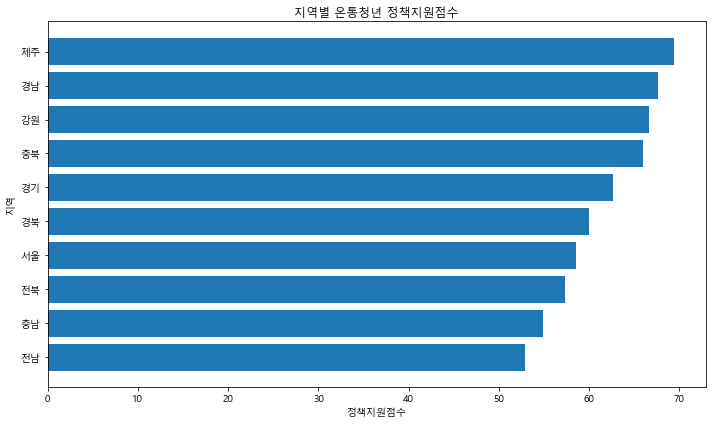

그림 저장: outputs\figures\policy_support_score_by_region.png


In [7]:
# 정책지원점수 시각화
plt.rcParams["axes.unicode_minus"] = False

def try_set_korean_font():
    candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]
    available = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams["font.family"] = font
            return font
    return None

selected_font = try_set_korean_font()
print("사용 폰트:", selected_font or "기본 폰트")

plot_df = score_df.sort_values("정책지원점수", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["지역"], plot_df["정책지원점수"])
plt.xlabel("정책지원점수")
plt.ylabel("지역")
plt.title("지역별 온통청년 정책지원점수")
plt.tight_layout()

fig_path = FIG_DIR / "policy_support_score_by_region.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("그림 저장:", fig_path)

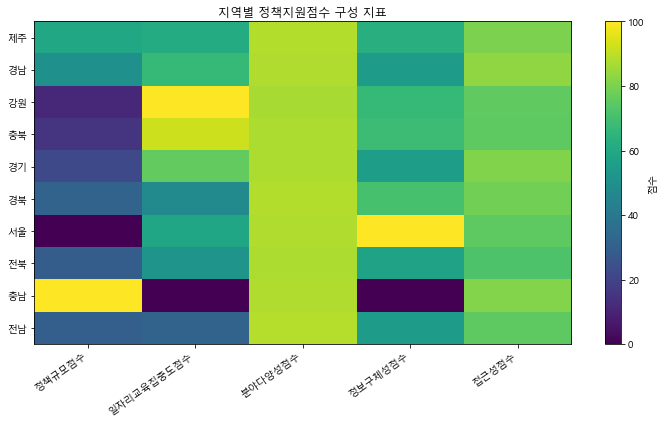

그림 저장: outputs\figures\policy_score_component_heatmap.png


In [8]:
# 지표별 점수 히트맵
component_cols = ["정책규모점수", "일자리교육집중도점수", "분야다양성점수", "정보구체성점수", "접근성점수"]
heat_df = (
    score_df
    .sort_values("정책지원점수", ascending=False)
    .set_index("지역")[component_cols]
)

plt.figure(figsize=(10, 6))
plt.imshow(heat_df.values, aspect="auto")
plt.xticks(range(len(component_cols)), component_cols, rotation=35, ha="right")
plt.yticks(range(len(heat_df.index)), heat_df.index)
plt.colorbar(label="점수")
plt.title("지역별 정책지원점수 구성 지표")
plt.tight_layout()

fig_path = FIG_DIR / "policy_score_component_heatmap.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("그림 저장:", fig_path)

## 채용공고 기반 일자리취약도 파일과 결합하기

팀원 안/박/김이 채용공고 분석으로 지역별 일자리취약도를 만들면,  
아래 형식의 `job_region_scores.csv` 파일을 노트북과 같은 폴더에 넣고 다음 셀을 실행합니다.

필수 컬럼:

| 컬럼명 | 의미 |
|---|---|
| 지역 | 서울, 경기, 강원, 충북, 충남, 전북, 전남, 경북, 경남, 제주 |
| 일자리취약도 | 높을수록 해당 지역의 채용공고상 일자리 여건이 취약함 |

선택 컬럼 예시:

| 컬럼명 | 의미 |
|---|---|
| 임금취약도 | 임금 관련 취약성 |
| 워라밸취약도 | 워라밸 관련 취약성 |
| 성장취약도 | 교육·경력성장 관련 취약성 |

In [11]:
# 팀원 결과 파일 템플릿 생성 또는 로드
JOB_SCORE_FILE = DATA_DIR / "job_region_scores.csv"
template_path = DATA_DIR / "job_region_scores_template.csv"

regions = score_df["지역"].sort_values().tolist()

if not JOB_SCORE_FILE.exists():
    template = pd.DataFrame({
        "지역": regions,
        "일자리취약도": np.nan,
        "임금취약도": np.nan,
        "워라밸취약도": np.nan,
        "성장취약도": np.nan,
        "비고": "팀원 채용공고 분석 결과 입력"
    })
    template.to_csv(template_path, index=False, encoding="utf-8-sig")
    print("job_region_scores.csv가 아직 없습니다.")
    print("아래 템플릿 파일에 팀원 분석 결과를 입력한 뒤 파일명을 job_region_scores.csv로 바꿔 다시 실행하세요.")
    print("템플릿 저장:", template_path)
    display(template)
else:
    job_score = read_csv_auto(JOB_SCORE_FILE)
    print("채용공고 기반 일자리취약도 파일 로드:", JOB_SCORE_FILE)
    display(job_score)

job_region_scores.csv가 아직 없습니다.
아래 템플릿 파일에 팀원 분석 결과를 입력한 뒤 파일명을 job_region_scores.csv로 바꿔 다시 실행하세요.
템플릿 저장: job_region_scores_template.csv


,지역,일자리취약도,임금취약도,워라밸취약도,성장취약도,비고
0,강원,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
1,경기,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
2,경남,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
3,경북,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
4,서울,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
5,전남,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
6,전북,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
7,제주,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
8,충남,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력
9,충북,NaN,NaN,NaN,NaN,팀원 채용공고 분석 결과 입력


In [10]:
# 일자리취약도 파일이 있을 때 정책 미스매치 점수 계산
if JOB_SCORE_FILE.exists():
    job_score = read_csv_auto(JOB_SCORE_FILE)

    if "지역" not in job_score.columns or "일자리취약도" not in job_score.columns:
        raise ValueError("job_region_scores.csv에는 최소한 '지역', '일자리취약도' 컬럼이 필요합니다.")

    mismatch = score_df.merge(job_score, on="지역", how="left")
    mismatch["일자리취약도_정규화"] = minmax_0_100(mismatch["일자리취약도"])
    mismatch["정책부족도"] = 100 - mismatch["정책지원점수"]

    # 취약도가 높고 정책지원점수가 낮을수록 미스매치가 크게 나오도록 설계
    mismatch["정책미스매치점수"] = (
        mismatch["일자리취약도_정규화"] * mismatch["정책부족도"] / 100
    ).round(2)

    def mismatch_level(x):
        if x >= 66:
            return "상"
        elif x >= 33:
            return "중"
        else:
            return "하"

    mismatch["미스매치수준"] = mismatch["정책미스매치점수"].apply(mismatch_level)
    mismatch = mismatch.sort_values("정책미스매치점수", ascending=False)

    display(mismatch)

    mismatch_path = OUTPUT_DIR / "job_policy_mismatch_score.csv"
    mismatch.to_csv(mismatch_path, index=False, encoding="utf-8-sig")
    print("미스매치 결과 저장:", mismatch_path)
else:
    print("job_region_scores.csv가 없어서 미스매치 계산은 건너뜁니다.")

job_region_scores.csv가 없어서 미스매치 계산은 건너뜁니다.


In [ ]:
# 미스매치 결과 시각화
if JOB_SCORE_FILE.exists():
    plot_df = mismatch.sort_values("정책미스매치점수", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["지역"], plot_df["정책미스매치점수"])
    plt.xlabel("정책미스매치점수")
    plt.ylabel("지역")
    plt.title("지역별 청년정책 미스매치 점수")
    plt.tight_layout()

    fig_path = FIG_DIR / "job_policy_mismatch_score_by_region.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("그림 저장:", fig_path)
else:
    print("job_region_scores.csv가 없어 미스매치 그래프를 생성하지 않았습니다.")

In [ ]:
# 결과 저장
score_path = OUTPUT_DIR / "policy_region_score.csv"
weights_path = OUTPUT_DIR / "policy_scoring_weights.csv"
category_matrix_path = OUTPUT_DIR / "policy_region_category_matrix.csv"

score_df.to_csv(score_path, index=False, encoding="utf-8-sig")
region_category.to_csv(category_matrix_path, encoding="utf-8-sig")
pd.DataFrame({
    "지표": list(weights.keys()),
    "가중치": list(weights.values())
}).to_csv(weights_path, index=False, encoding="utf-8-sig")

print("저장 완료")
print("-", score_path)
print("-", weights_path)
print("-", category_matrix_path)

## 보고서에 쓸 수 있는 문장 예시

본 연구에서는 온통청년 API로 수집한 지역별 청년정책 데이터를 바탕으로 정책공급 수준을 정량화하였다.  
정책지원점수는 정책 수, 일자리·직무교육 관련 정책 비중, 정책 분야 다양성, 정책 설명의 구체성, 신청 URL 제공 여부를 0~100점으로 정규화한 뒤 가중합 방식으로 산출하였다.  
이후 채용공고 텍스트 분석을 통해 도출된 지역별 일자리취약도와 결합하여, 일자리 여건은 취약하지만 관련 정책지원 수준이 낮은 지역을 정책 미스매치 지역으로 해석하였다.